## Retrievers

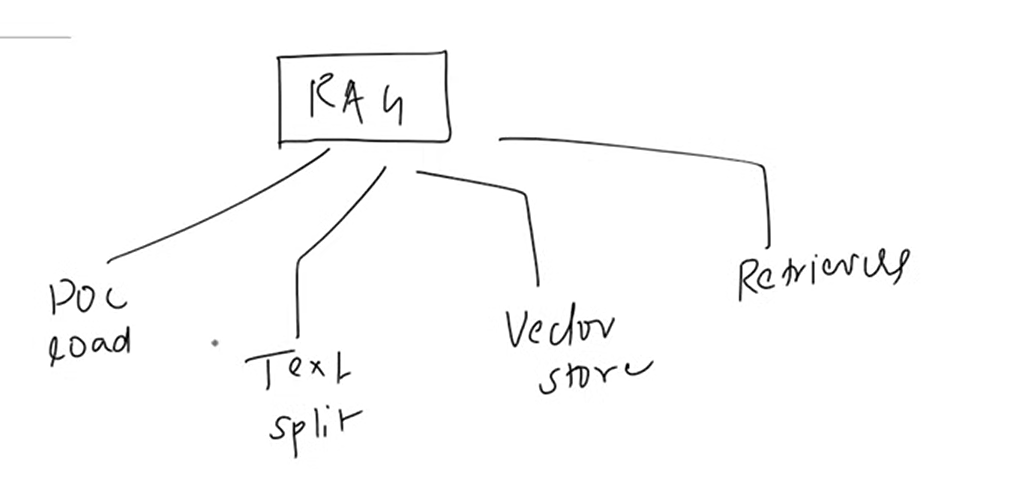

## What is a Retriever ?

A retriever is a component in langchain that fetches relevant documents from a data source in response to a user's query.

There are multiple types of retrievers

All Retrievers in LangChain are runnables

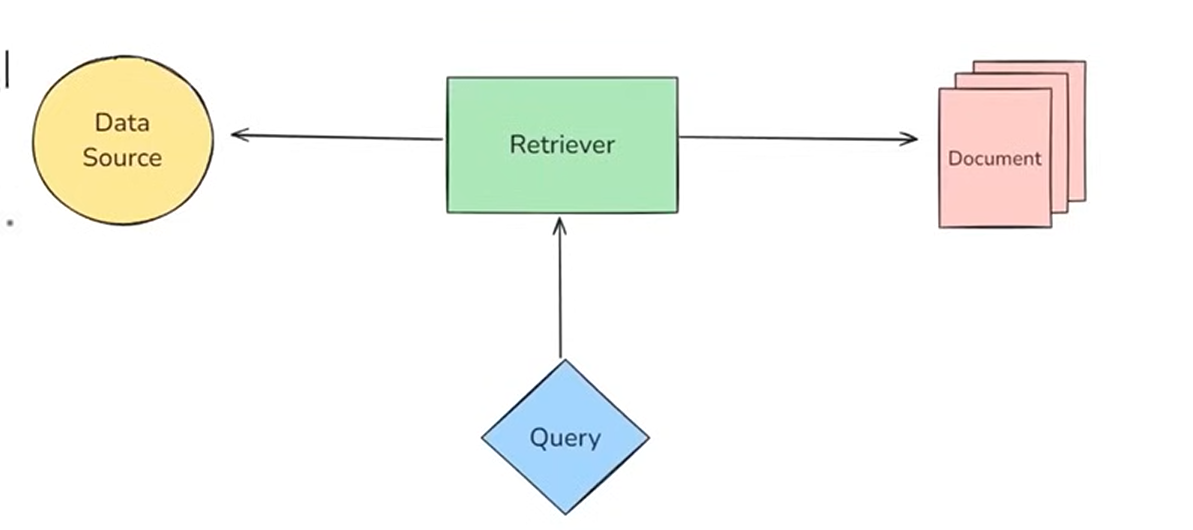

Data Source could be a vector store, API or normal database



In [2]:
## Retriever is like a function

##  Query -> function -> multiple doc objects

## Retriever is like a search enginer

In [4]:
## we can create chains using Retrievers and can plug-in retrievers

## Types of Retrievers:

On the basis of what kind of Data source is being used:
* Wikipidea retriever -> searches user query on wikipedia to fetch relevant wikipedia articles
* Vector Store retriever -> searches user query on vector store and fetches most relevant documents
* Arxiv Retriever -> Find all relevant research papers and give relevant results


On the basis of Search Strategy:
* Maximum Marginal Relevance (MMR)
* Multi Query Retriever (MQR)
* Contextual Compression Retrievers (CCR)

All these retrievers have different ways of searching



## Wikipedia Retriever

A Wikipidea Retriever is a retriever that queries the Wikipedia API to fetch relevant content for a given query.

How it works:

1. You give it a query (eg. "Albert Einstein")
2. It sends the query to Wikipedia API
3. It retrieves the most relevant articles (Keyword-based matching is used)
4. It returns them as LangChain Document Objects

In [2]:
!pip install wikipedia

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11757 sha256=a0207bb60086aba879176a30c1f65daf6f08ee810543ab6078ca9c4208e7b4d6
  Stored in directory: /Users/priyanshugupta/Library/Caches/pip/wheels/79/1d/c8/b64e19423cc5a2a339450ea5d145e7c8eb3d4aa2b150cde33b
Successfully built wikipedia


In [ ]:
from langchain_community.retrievers import WikipediaRetriever

## Initalize the retriever (optional: set the language and top_k_results)

retriever = WikipediaRetriever(top_k_results=3, lang='en')

## define the query

query="The geopolitical history of India and Pakistan from the perspective of a Chinese"


## Get the relevant Wikipedia Documents

docs=retriever.invoke(query)
## hitting api of wikipedia

In [6]:
for i,document in enumerate(docs):
    print(f"\n-- Result {i+1}---")
    print(f"Content:\n{document.page_content}...")


-- Result 1---
Content:
The India–Pakistan war of 1971, also known as the third Indo-Pakistani war, was a military confrontation between India and Pakistan that occurred during the Bangladesh Liberation War in East Pakistan from 3 December 1971 until the Pakistani capitulation in Dhaka on 16 December 1971.  The war began with Pakistan's Operation Chengiz Khan, consisting of preemptive aerial strikes on eight Indian air stations. The strikes led to India declaring war on Pakistan, marking their entry into the war for East Pakistan's independence, on the side of Bengali nationalist forces. India's entry expanded the existing conflict with Indian and Pakistani forces engaging on both the eastern and western fronts.
Thirteen days after the war started, India achieved a clear upper hand, and the Eastern Command of the Pakistan military signed the instrument of surrender on 16 December 1971 in Dhaka, marking the formation of East Pakistan as the new nation of Bangladesh. Approximately 93,00

Document Loader vs Retriever

Unlike Document loader it doesn't load all the documents, instead there is some intelligence search performed and only relevant documents are fetched

## Vector Store Retriever

A vector store retriever in LangChain is the most common type of Retriever that lets you search and fetch documents from a Vector Store based on sementic Similarity using vector embeddings.

How it Works:
1. You store your documents in a Vector Store(Like Chroma, FAISS, Weaviate)
2. Each document is converted into a dense vector using a embedding model
3. When the user enters a query:
   - It is also turned into a vector
   - The Retriever compares the query vector with the stored vectors
   - It retrieves the top-k most similar ones

FAISS(
    embedding_function,
    index,
    docstore,
    index_to_docstore_id
)

In [5]:
%pip install -U faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.9 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

## Step 1: Your Source Documents

documents=[
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content='Chroma is a vector database optimized for LLM-Based search.'),
    Document(page_content='OpenAI provides powerful embedding models.')
]

## Step 2: Initalize your embedding model

embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


## Step 3: Create FAISS vector store in memory

vectorstore = FAISS.from_documents(
    documents,
    embedding_model
)

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_72392/3008401027.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [19]:
## Step 4: Create FAISS Retriever from FAISS Vector Store

retriever = vectorstore.as_retriever(search_kwargs={"k":1})

In [20]:
## Step 5: Define query

query="What is Chroma used for ?"

results=retriever.invoke(query)


In [21]:
for i,doc in enumerate(results):
    print(f"\n---Result {i+1}----")
    print(f"---Content---\n {doc.page_content}")


---Result 1----
---Content---
 Chroma is a vector database optimized for LLM-Based search.


# Q We can use Vector store also for that ?

In [26]:
doc=vectorstore.similarity_search("What is Chroma used for ?",k=1)
doc[0].page_content

'Chroma is a vector database optimized for LLM-Based search.'

# A:

Vector Store has capability to do similarity search but it only uses one strategy, it compares all vectors with query vector with one metric and gives top_k docs. What if we want different strategy ? then we cannot use vector Store.

With Retrievers, we can try out different search strategies.

## Maximum Marginal Retriever (MMR)

Idea: "How can we pick results such that they are not only relevant to the query but also different from each other?"

MMR is an information retrieval algorithm designed to reduce redundancy in the retrieved results while maintaining high relevance to the query

# Why MMR ?

In regular similarity search, you may get documents that are:
- All very similar to each other
- Repeating the same info
- Lacking diverse perspectives

MMR Retriever avoids that by:
- Picking the most relevant document first
- Then picking the next most relevant document and least similar to the already selected documents.
- And so on... 

This helps the RAG pipelines where:
- You want your context window to contain diverse but still relevant information
- Especially useful when documents are sementaically overlapping


Example:

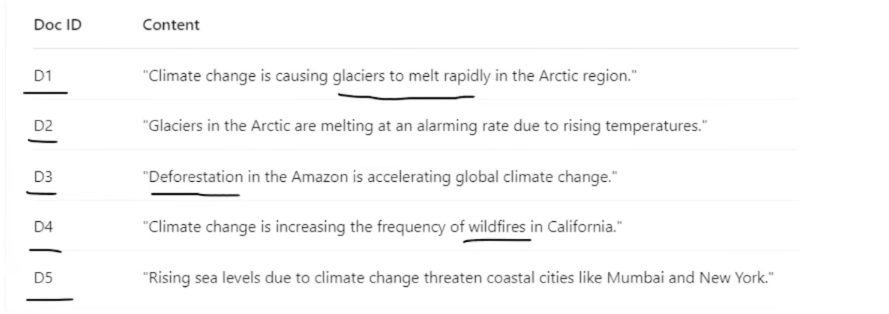

If we send to a normal retreiver , What are the adverse affects of climate change ?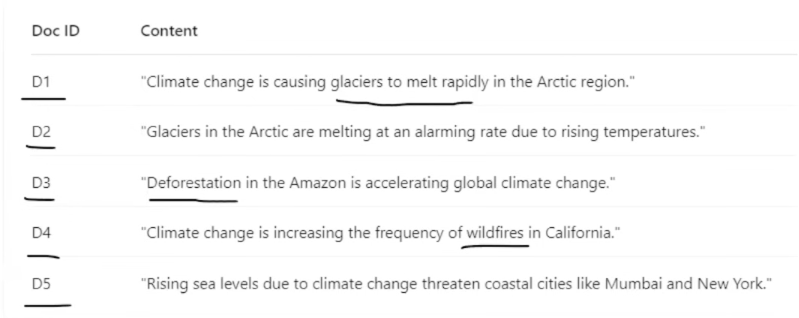

Normal Retriever will do normal similarity search , we might get redundant results 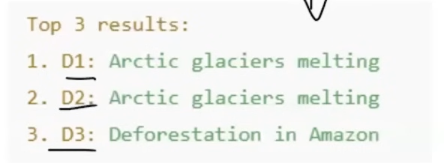

first two statements tell about the same thing,


Ideal result: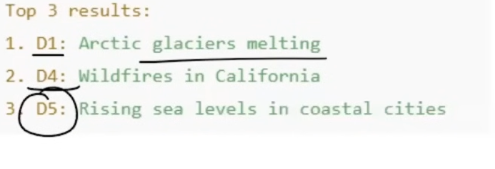



In [33]:
%pip install -U qdrant-client langchain-qdrant

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [langchain-qdrant][qdrant-client]
Note: you may need to restart the kernel to use updated packages.


In [50]:
from langchain_qdrant import QdrantVectorStore
## Initalize the Huggingface embedding
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


documents=[
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="Langchain is an open source framework build to connect LLMs with apps, tools and Databases, it helps in maintaing memory."),
    Document(page_content="Langchain is an open source framework build to connect LLMs with apps, tools and Databases, it helps in maintaing memory."),
    Document(page_content='Chroma is a vector database optimized for LLM-Based search.'),
]


## Step 2: Create the Redist vector store from the documents

vectorstore = QdrantVectorStore.from_documents(
    documents=documents,
    embedding=embedding_model,
    location=":memory:",
    collection_name="my_documents"
)
## Enable MMR in the Retriever

retriever = vectorstore.as_retriever( 
    search_kwargs={"k":3, "lambda_mult":1},  # k= top_results and lambda_mult= Relevance-diversity balance
    search_type="mmr" ## <--- This enables MMR

)

## lambda_mult varies from 0 to 1 and 1 means too much diverse results
query="What is langchain ?"
results= retriever.invoke(query)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [51]:
results[0].page_content

'Langchain is an open source framework build to connect LLMs with apps, tools and Databases, it helps in maintaing memory.'

In [52]:
results[1].page_content

'Chroma is a vector database optimized for LLM-Based search.'

In [53]:
results[2].page_content

'LangChain helps developers build LLM applications easily.'

## Multi Query Retriever

Query -> Vector Store

It might be possible, the query that the user sends might be ambiguous. if the meaning is not clear then the search performed must be poor

Sometimes a single query might not capture all the ways information is phrased in your documents.

Query: "How can I stay Healthy ? "

It could mean:
- What should I eat?
- How often should I exercise ?
- How can I manage Stress ?

A simple similarity search might miss documents that talk about those things but do not use the word "Healthy".



MQR What it does:

1. Takes your original query
2. Uses an LLM (eg GPT-3.5) to generate multiple sementically different versions of that query
3. Performs retrieval for each sub query
4. Combines and deduplicates the results


"How can I stay Healthy" -> LLM -> generates many sub queries

Sub-Queries:

- What are the best foods to maintain a good health?
- How often should I exercise to stay fit ?
- What lifestyle habits improve mental and physical welness ?
- How can I boost my immune system naturally?
- What daily routines support long-term health ?

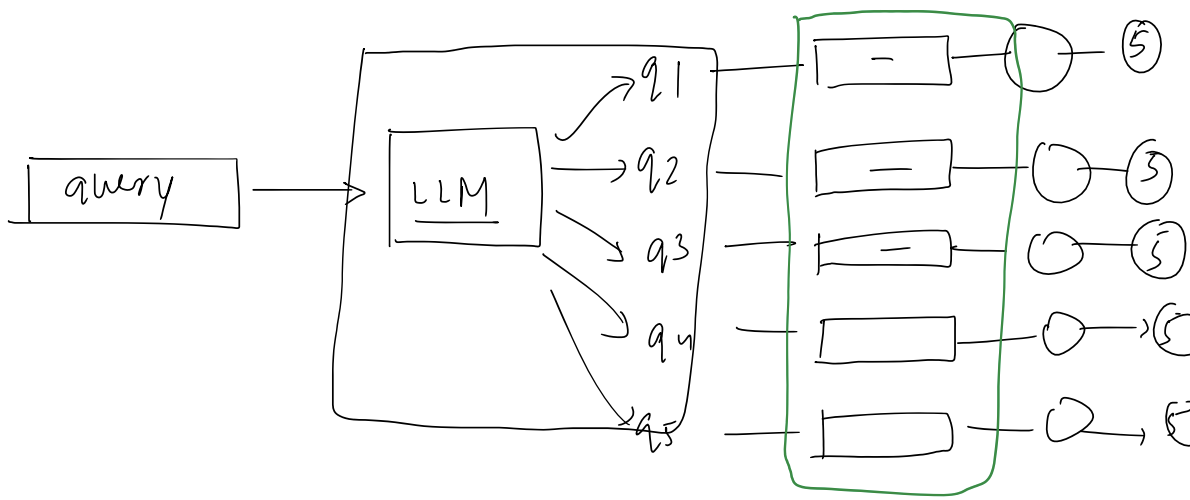

In [54]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_classic.retrievers.multi_query import MultiQueryRetriever
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from dotenv import load_dotenv

load_dotenv()

True

In [55]:
## Relevant Health and welness documents

all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]


In [56]:
## Initalize Huggingface embeddings

embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


## Create FAISS Vector store 

vectorstore=FAISS.from_documents(embedding=embedding_model, documents=all_docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
## Create retreivers

llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen3-4B-Instruct-2507',
    task='text-generation'
)

model=ChatHuggingFace(llm=llm)
similarity_retreiver=vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={"k":5}
)
## MultiQueryRetriever.from_llm(llm , retrieval)

multiquery_retriever=MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs={"k":5}),
    llm=model
)

In [62]:
query="How to improve energy levels and maintain balance"

## Retrieve results

similarity_results=similarity_retreiver.invoke(query)
multiquery_results=multiquery_retriever.invoke(query)

In [63]:
for i,doc in enumerate(similarity_results):
    print(f"\n ---Result {i+1}----")
    print(doc.page_content)


 ---Result 1----
Drinking sufficient water throughout the day helps maintain metabolism and energy.

 ---Result 2----
The solar energy system in modern homes helps balance electricity demand.

 ---Result 3----
Consuming leafy greens and fruits helps detox the body and improve longevity.

 ---Result 4----
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

 ---Result 5----
Photosynthesis enables plants to produce energy by converting sunlight.


In [64]:
for i,doc in enumerate(multiquery_results):
    print(f"\n ---Result {i+1}----")
    print(doc.page_content)


 ---Result 1----
Drinking sufficient water throughout the day helps maintain metabolism and energy.

 ---Result 2----
Regular walking boosts heart health and can reduce symptoms of depression.

 ---Result 3----
Consuming leafy greens and fruits helps detox the body and improve longevity.

 ---Result 4----
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

 ---Result 5----
The solar energy system in modern homes helps balance electricity demand.

 ---Result 6----
Deep sleep is crucial for cellular repair and emotional regulation.

 ---Result 7----
Photosynthesis enables plants to produce energy by converting sunlight.


## Contextual Compression Retriever

The contextual Compression Retriever (CCR) in LangChain is an advanced retriever that improves retrival quality by compressing documents after retrieval - Keeping only the relevant content based on the user's query.

Query: " What is photosynthesis"

Retrieved Document (By Traditional Retriever):

"The Grand Canyon is a famous natural site. Photosynthesis is how plants convert light into energy. Many tourist visit every year."


## Problem:

- The retriever returns the entire paragraph
- Only one sentence is actually relevant to the query
- The rest is irrelevant noise that wastes the context window and may confused the LLM

## What contextual Compression Retriever does:

Returns only the relevant part. Eg:"Photosynthesis is how plants convert light into energy."

## How it works:

1. Base Retriever (eg. FAISS, Chroma) retrieves N documents
2. A compressor (usually an LLM) is applied to each document
3. The compressor keeps only the parts relevant to the query
4. Irrelevant content is discarded


## When to use:
- Your documents are long and contain mixed information
- You want to reduce context length for LLMs
- you need to improve answer accuracy in RAG pipeline

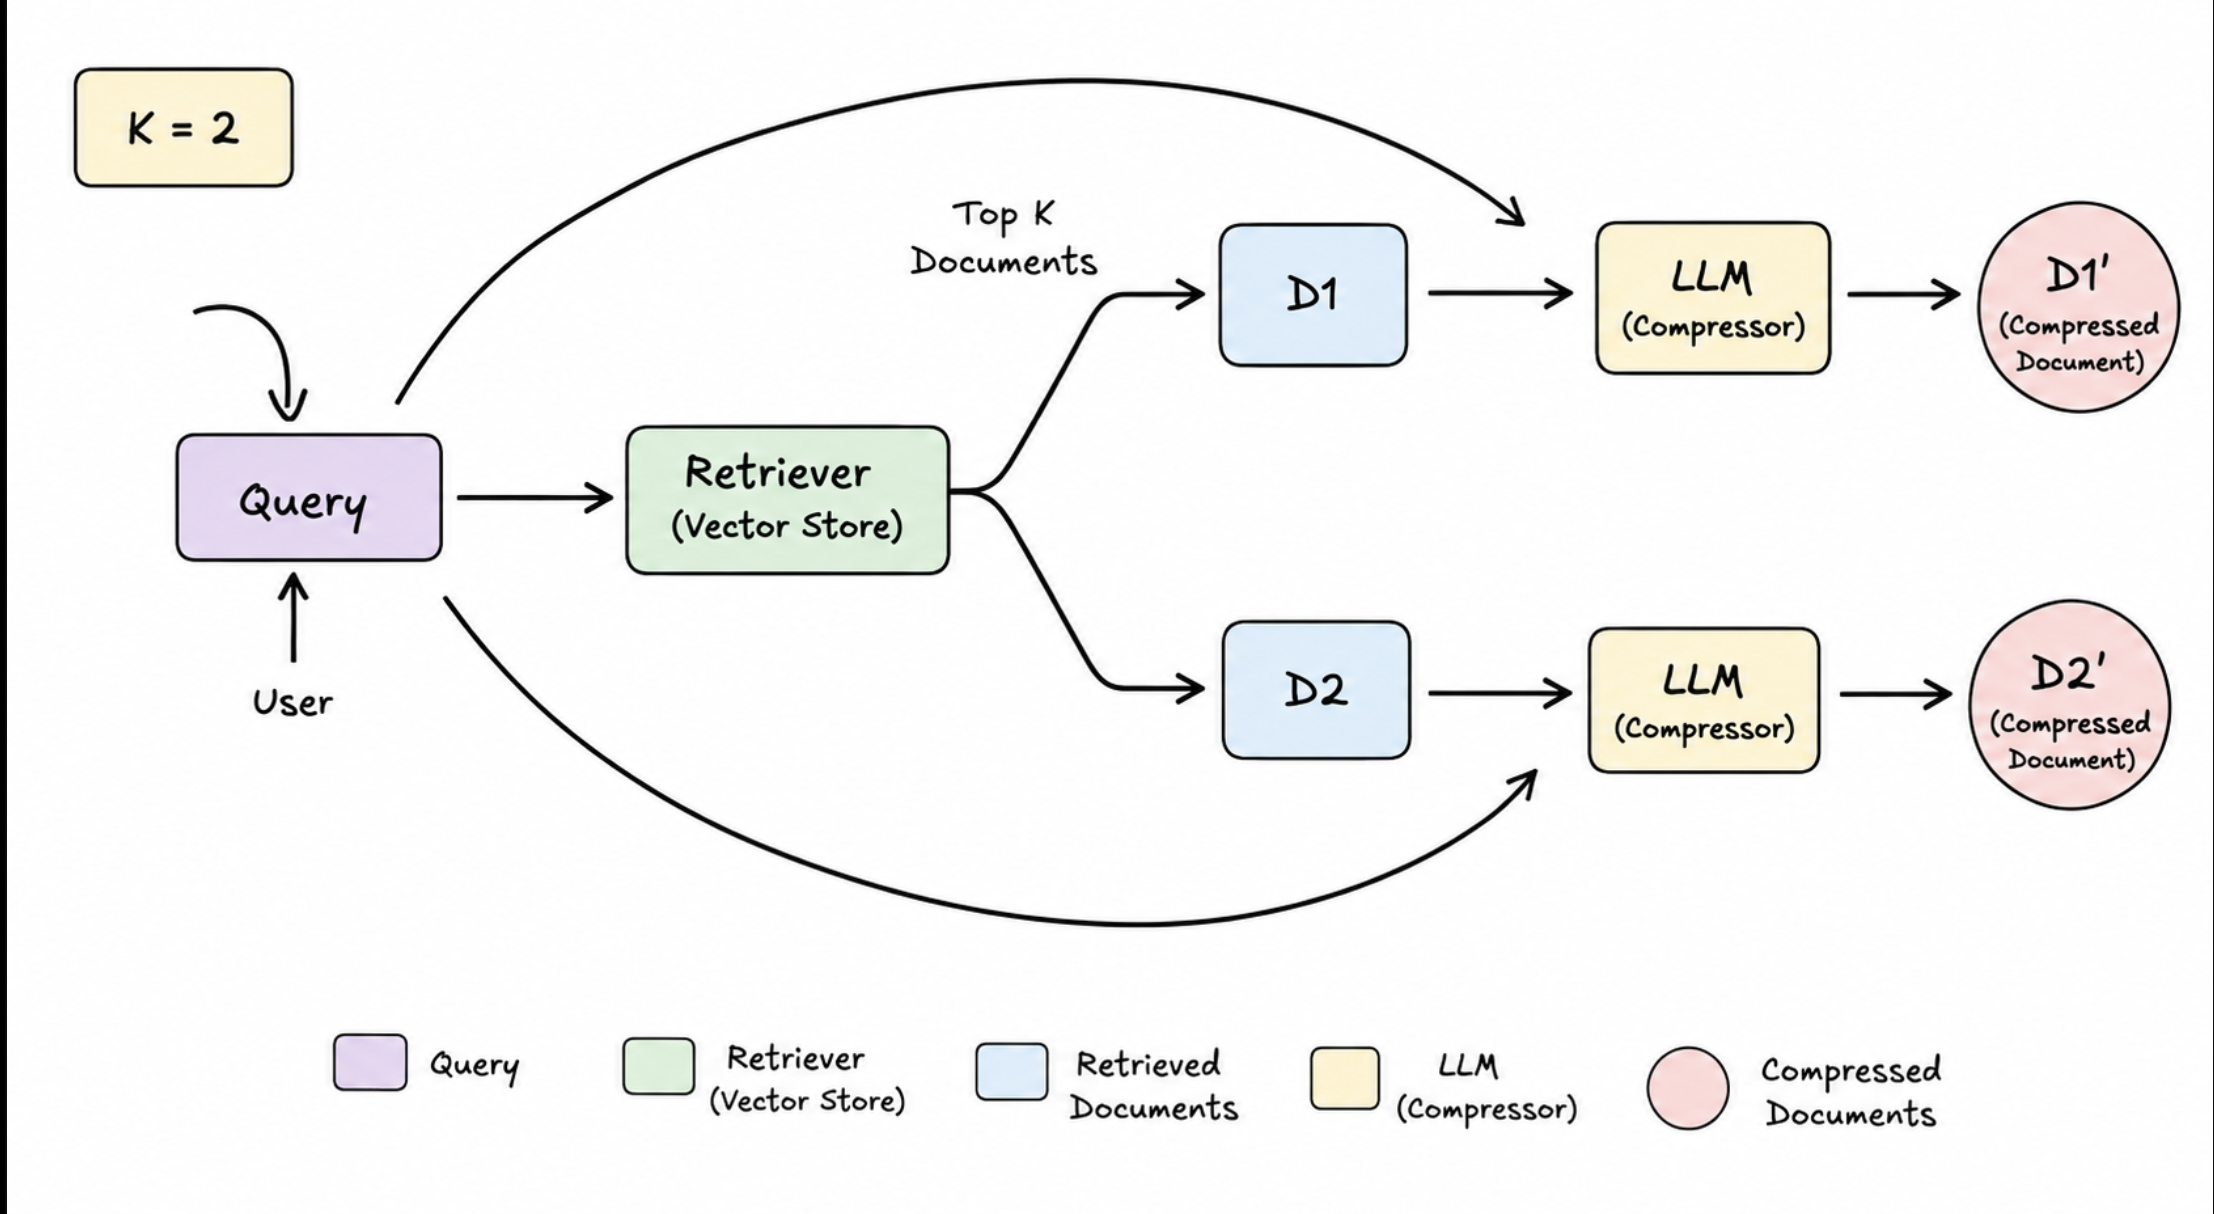

In [65]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from dotenv import load_dotenv
from langchain_classic.retrievers import ContextualCompressionRetriever

load_dotenv()

True

In [67]:
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


docs = [
    Document(
        page_content=(
            """The Grand Canyon is one of the most visited natural wonders in the world.
Photosynthesis is the process by which green plants convert sunlight into energy.
Millions of tourists travel to see it every year. The rocks date back millions of years."""
        ),
        metadata={"source": "Doc1"}
    ),

    Document(
        page_content=(
            """In medieval Europe, castles were built primarily for defense.
The chlorophyll in plant cells captures sunlight during photosynthesis.
Knights wore armor made of metal. Siege weapons were often used to breach castle walls."""
        ),
        metadata={"source": "Doc2"}
    ),

    Document(
        page_content=(
            """Basketball was invented by Dr. James Naismith in the late 19th century.
It was originally played with a soccer ball and peach baskets. NBA is now a global league."""
        ),
        metadata={"source": "Doc3"}
    ),

    Document(
        page_content=(
            """The history of cinema began in the late 1800s. Silent films were the earliest form.
Thomas Edison was among the pioneers. Photosynthesis does not occur in animal cells.
Modern filmmaking involves complex CGI and sound design."""
        ),
        metadata={"source": "Doc4"}
    )
]

## Create a FAISS Vector store from the documents

vectorstore=FAISS.from_documents(embedding=embedding_model,documents=docs)

base_retriever=vectorstore.as_retriever(select_kwargs={"k":5})


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [73]:
from langchain_classic.retrievers.document_compressors import LLMChainExtractor
## Setup compressor for Contextual Compression Retriever
llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen3-4B-Instruct-2507',
    task='text-generation'
)

model=ChatHuggingFace(llm=llm)
compressor=LLMChainExtractor.from_llm(model)
## For LLM-based contextual compression, wrap your LLM with LLMChainExtractor.



## Create the Contextual Compressor Retriever

contextual_retriever=ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=base_retriever
)

## ContextualCompressionRetriever( 1. base_compressor, base_retriever)


In [74]:
query="What is Photosynethesis ?"

result=contextual_retriever.invoke(query)

for i,doc in enumerate(result):
    print(f"\n ---Result {i+1}---")
    print(f"{doc.page_content}")


 ---Result 1---
Photosynthesis is the process by which green plants convert sunlight into energy.

 ---Result 2---
The chlorophyll in plant cells captures sunlight during photosynthesis.

 ---Result 3---
Photosynthesis does not occur in animal cells.


## More Retrievers:

1. ParentDocumentRetriever
2. ArxivRetriever
3. EnsembleRetriever
4. BM25Retriever
5. SelfQueryRetriever
6. MultiVectorRetriever
7. TimeWeightedVectorRetriever